# Botaanika

In [34]:
!pip3 install seaborn --upgrade
!pip3 install matplotlib
!pip3 install pandas
!pip3 install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [41]:
import pandas as pd
import seaborn as sns
import numpy as np


In [15]:

# Load the iris dataset into a pandas DataFrame
iris = sns.load_dataset('iris')

iris.to_csv("iris.csv", index=False)

# Display the first few rows
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## CSV faili lugemine

In [16]:
iris = pd.read_csv("iris.csv")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


<Axes: xlabel='petal_width', ylabel='Density'>

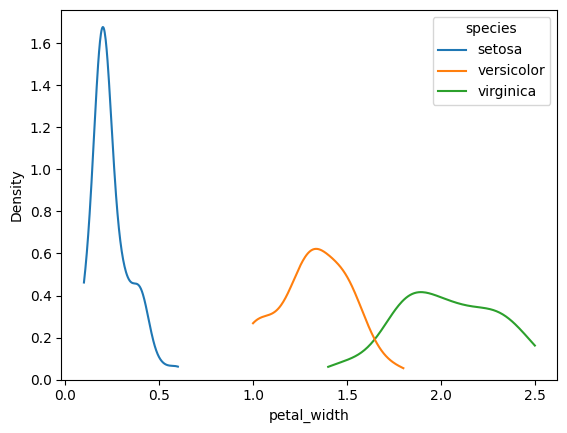

In [17]:
sns.kdeplot(iris, x="petal_width", cut=0, hue="species")

<Axes: xlabel='petal_width', ylabel='Count'>

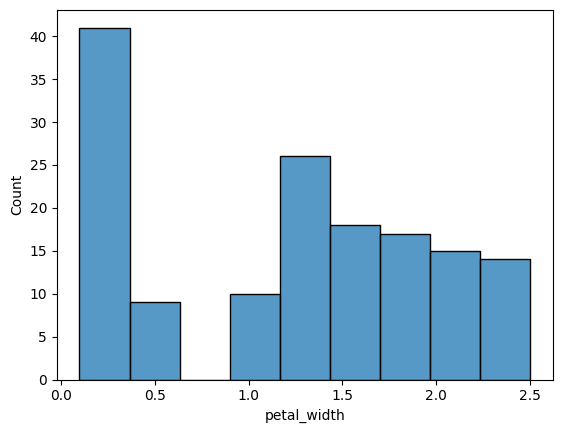

In [18]:
sns.histplot(iris,  x="petal_width")

<Axes: xlabel='petal_length', ylabel='species'>

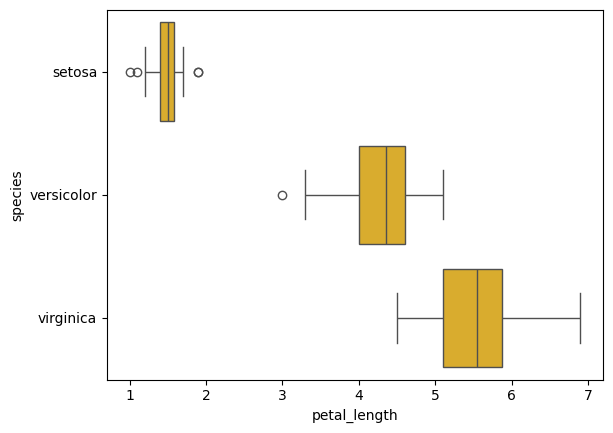

In [19]:
sns.boxplot(iris, x="petal_length", y="species", color="#f6b911")

<Axes: xlabel='petal_length', ylabel='species'>

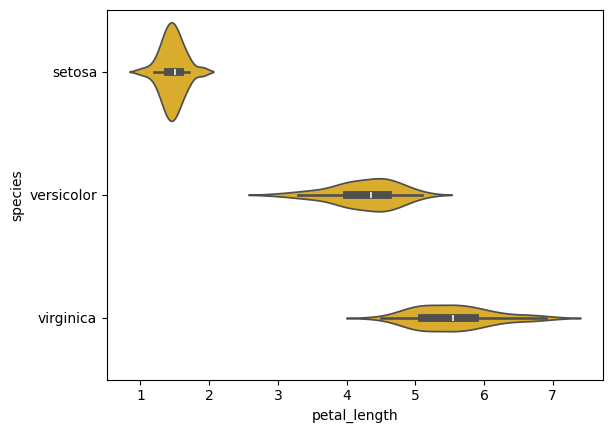

In [20]:
sns.violinplot(iris, x="petal_length", y="species", color="#f6b911")

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

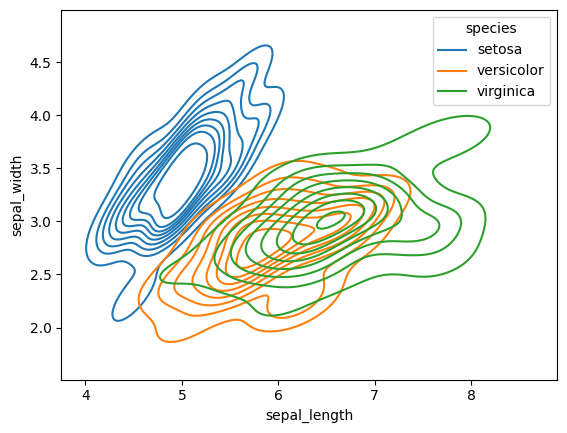

In [26]:
sns.kdeplot(iris, x="sepal_length", y="sepal_width", hue="species")

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

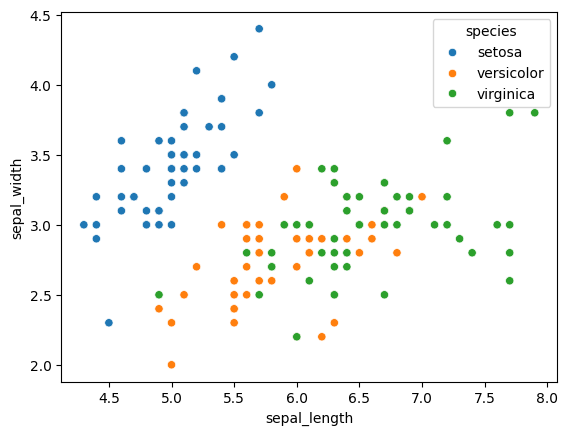

In [27]:
sns.scatterplot(iris, x="sepal_length", y="sepal_width", hue="species")

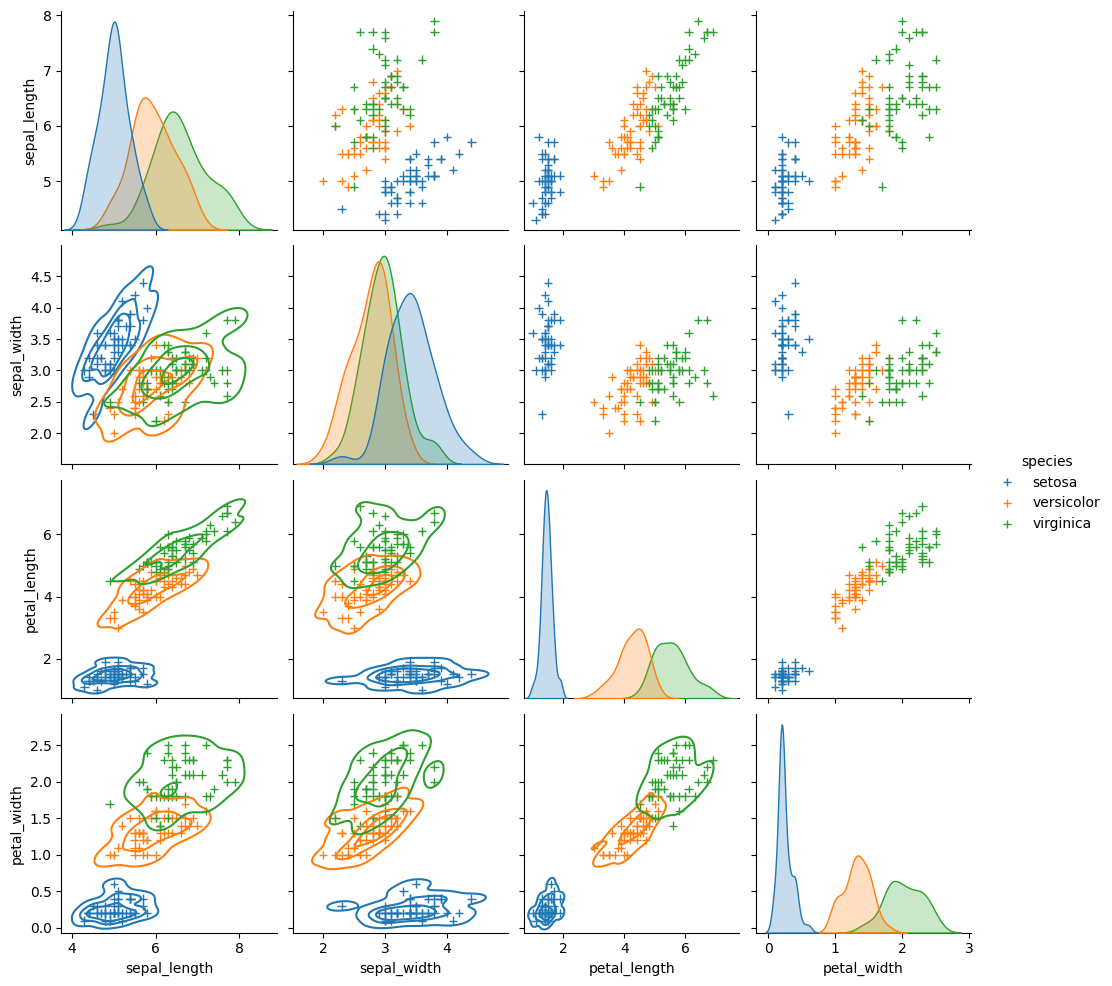

In [33]:
sns.pairplot(
    iris,
    hue="species",
    plot_kws=dict(marker="+", linewidth=1),
).map_lower(sns.kdeplot, levels=4)


## Ennustavate mudelite

### Test-train-split

In [55]:
np.random.seed(42)

n_samples = len(iris)
n_test = int(0.3 * n_samples)
split_flags = np.zeros(n_samples, dtype=int)
test_indices = np.random.choice(n_samples, size=n_test, replace=False)
split_flags[test_indices] = 1

iris["test_train"] = split_flags
iris

,sepal_length,sepal_width,petal_length,petal_width,species,test_train
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,1
146,6.3,2.5,5.0,1.9,virginica,1
147,6.5,3.0,5.2,2.0,virginica,0
148,6.2,3.4,5.4,2.3,virginica,0


<Axes: xlabel='petal_width', ylabel='petal_length'>

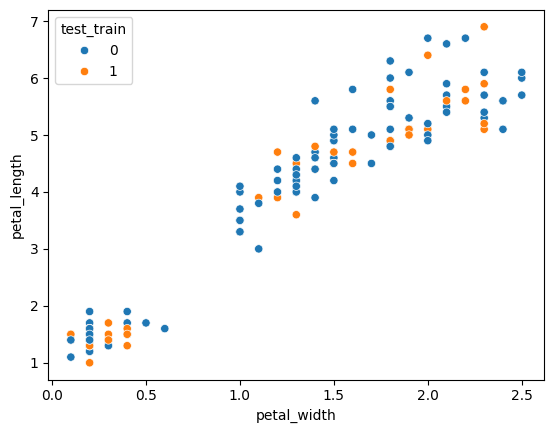

In [56]:
sns.scatterplot(iris, x="petal_width", y="petal_length", hue="test_train")

<Axes: xlabel='petal_width', ylabel='petal_length'>

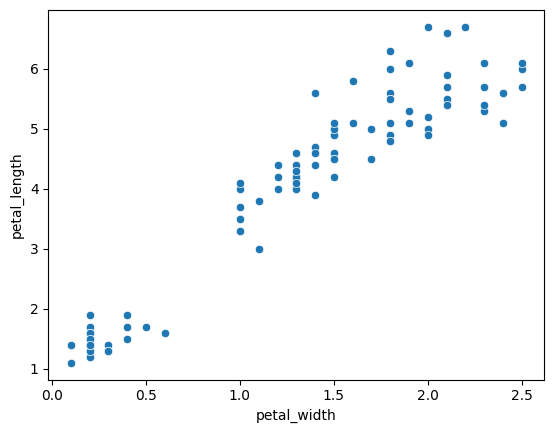

In [49]:
train_data = iris[iris["test_train"] == 0]

sns.scatterplot(train_data, x="petal_width", y="petal_length")

<Axes: xlabel='petal_width', ylabel='petal_length'>

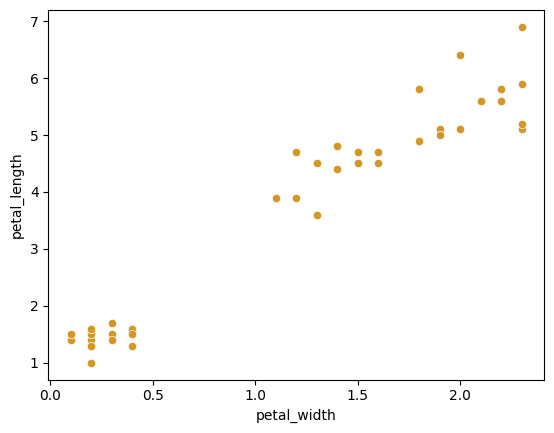

In [52]:
test_data = iris[iris["test_train"] == 1]

sns.scatterplot(test_data, x="petal_width", y="petal_length", color="#D49725")

In [53]:
def funktsioon(arg1, arg2, *args, **kwargs):
    print(arg1)
    print(arg2)
    print(args)
    print(kwargs)
    

In [54]:
funktsioon("Esimene argument", "Teine argument", "Veel mingi argument", "Üks veel", nimi="Juhan", elu="hea")

Esimene argument
Teine argument
('Veel mingi argument', 'Üks veel')
{'nimi': 'Juhan', 'elu': 'hea'}


In [57]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()


model.fit(train_data[["petal_width"]], train_data["petal_length"])



LinearRegression()

In [58]:
petal_length_result = model.predict(test_data[["petal_width"]])
petal_length_result

array([1.56379303, 1.34179327, 1.56379303, 1.56379303, 1.34179327,
       2.00779254, 2.00779254, 1.78579278, 1.78579278, 1.56379303,
       2.00779254, 1.56379303, 1.56379303, 1.56379303, 2.00779254,
       1.34179327, 1.56379303, 1.56379303, 1.78579278, 4.44978984,
       4.00579033, 4.67178959, 4.00579033, 4.22779008, 4.44978984,
       3.56179082, 3.78379057, 4.22779008, 4.44978984, 3.78379057,
       4.67178959, 4.44978984, 6.00378812, 5.1157891 , 5.55978861,
       6.22578787, 5.1157891 , 5.78178836, 5.55978861, 6.00378812,
       6.22578787, 5.33778885, 6.22578787, 6.22578787, 5.33778885])

<Axes: xlabel='petal_width', ylabel='petal_length'>

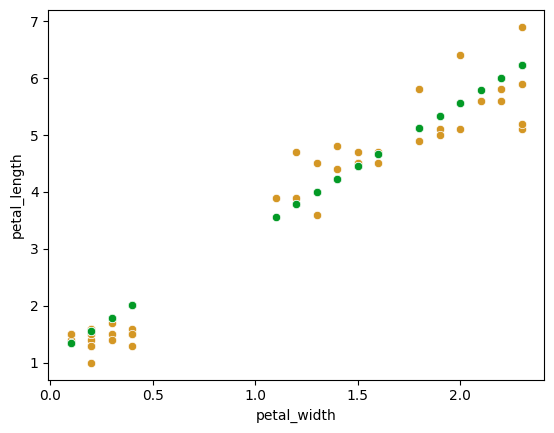

In [60]:
sns.scatterplot(test_data, x="petal_width", y="petal_length", color="#D49725")
sns.scatterplot(x=test_data["petal_width"], y=petal_length_result, color="#039A26")


<Axes: >

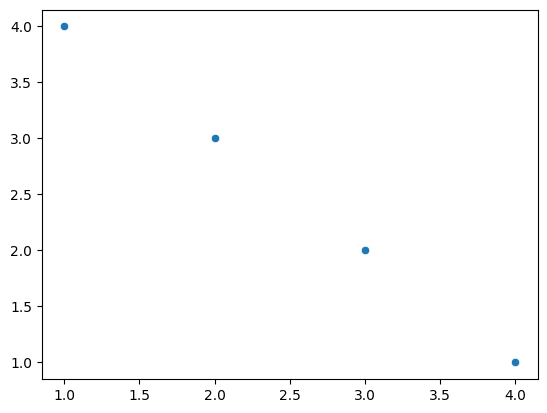

In [66]:
sns.scatterplot(x=[1, 2, 3, 4], y=[4, 3, 2, 1])


In [61]:
from sklearn.metrics import r2_score

In [63]:
round(
    r2_score(test_data["petal_length"], petal_length_result),
    2
)

0.94